# 03 - Exploratory Data Analysis (EDA)

## Objective
This notebook explores the telco churn dataset to identify important patterns, distributions, and early business insights related to customer churn.

## Goals
- examine the distribution of the target variable
- inspect key categorical and numeric variables in relation to churn
- identify patterns that may inform preprocessing and modeling decisions

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [12]:
df = pd.read_csv("../data/raw/telco.csv")
df.head()

,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,City,Zip Code,Latitude,Longitude,Population,Quarter,Referred a Friend,Number of Referrals,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,Internet Service,Internet Type,Avg Monthly GB Download,Online Security,Online Backup,Device Protection Plan,Premium Tech Support,Streaming TV,Streaming Movies,Streaming Music,Unlimited Data,Contract,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,Los Angeles,90022,34.023810,-118.156582,68701,Q3,No,0,1,NaN,No,0.00,No,Yes,DSL,8,No,No,Yes,No,No,Yes,No,No,Month-to-Month,Yes,Bank Withdrawal,39.65,39.65,0.00,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,Los Angeles,90063,34.044271,-118.185237,55668,Q3,Yes,1,8,Offer E,Yes,48.85,Yes,Yes,Fiber Optic,17,No,Yes,No,No,No,No,No,Yes,Month-to-Month,Yes,Credit Card,80.65,633.30,0.00,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,Los Angeles,90065,34.108833,-118.229715,47534,Q3,No,0,18,Offer D,Yes,11.33,Yes,Yes,Fiber Optic,52,No,No,No,No,Yes,Yes,Yes,Yes,Month-to-Month,Yes,Bank Withdrawal,95.45,1752.55,45.61,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,Inglewood,90303,33.936291,-118.332639,27778,Q3,Yes,1,25,Offer C,Yes,19.76,No,Yes,Fiber Optic,12,No,Yes,Yes,No,Yes,Yes,No,Yes,Month-to-Month,Yes,Bank Withdrawal,98.50,2514.50,13.43,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,Whittier,90602,33.972119,-118.020188,26265,Q3,Yes,1,37,Offer C,Yes,6.33,Yes,Yes,Fiber Optic,14,No,No,No,No,No,No,No,Yes,Month-to-Month,Yes,Bank Withdrawal,76.50,2868.15,0.00,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges


In [13]:
eda_df = df.copy()

none_like_cols = ["Offer", "Internet Type", "Churn Category", "Churn Reason"]
for col in none_like_cols:
    if col in eda_df.columns:
        eda_df[col] = eda_df[col].replace("None", pd.NA)

## Churn Label Distribution

In [14]:
eda_df["Churn Label"].value_counts()

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

In [15]:
eda_df["Churn Label"].value_counts(normalize=True)

Churn Label
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

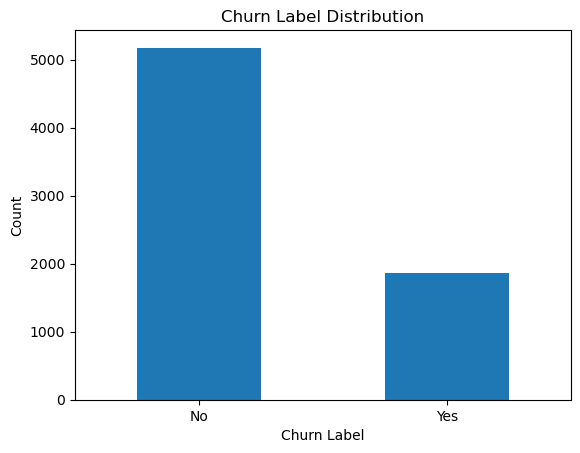

In [16]:
eda_df["Churn Label"].value_counts().plot(kind="bar")
plt.title("Churn Label Distribution")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

This distribution shows the balance between churned and non-churned customers in the dataset.

The target appears imbalanced, which may later influence metric selection and model evaluation.

## Contract Type vs Churn

In [17]:
contract_churn = pd.crosstab(eda_df["Contract"], eda_df["Churn Label"], normalize="index")
contract_churn

Churn Label,No,Yes
Contract,,
Month-to-Month,0.541551,0.458449
One Year,0.892903,0.107097
Two Year,0.974509,0.025491


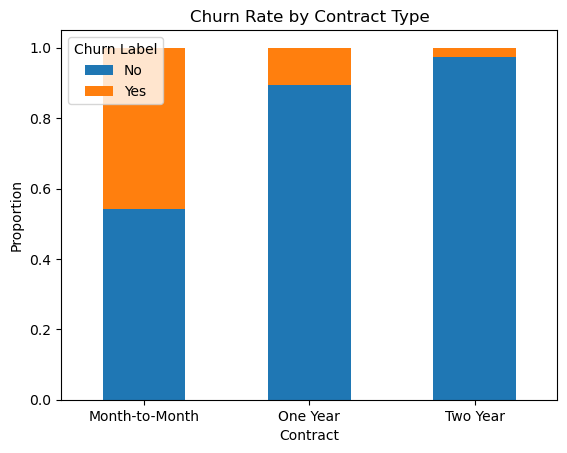

In [18]:
contract_churn.plot(kind="bar", stacked=True)
plt.title("Churn Rate by Contract Type")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.show()

### Interpretation

Churn varies strongly across contract types.

Customers on month-to-month contracts show the highest churn share, while customers on longer contracts—especially two-year contracts—show much lower churn rates.

This suggests that `Contract` is likely to be an important predictive feature in the modeling stage.

### Monthly Charges vs. Churn

<Axes: xlabel='Churn Label', ylabel='Monthly Charge'>

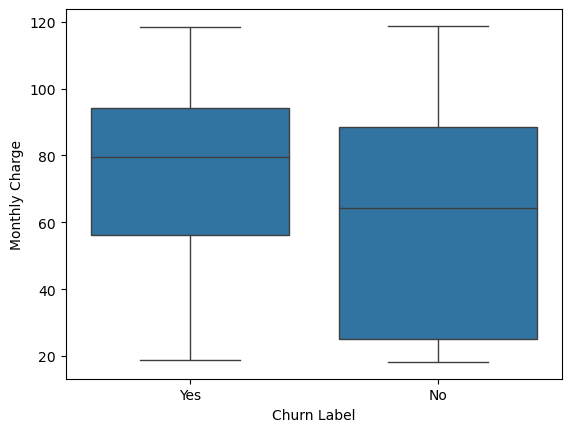

In [21]:
import seaborn as sns
sns.boxplot(x="Churn Label", y="Monthly Charge", data=eda_df)


This boxplot compares the distribution of monthly charges for churned and non-churned customers.

Key Observations:
- **Higher Median Cost:** Customers who churn (Yes) have a noticeably higher median monthly charge compared to those who stay (No).
- **Price Sensitivity:** The concentration of churned customers in the higher price range suggests that high costs may be a significant driver of customer loss.
- **Retention in Lower Brackets:** Non-churned customers show a wider distribution with a lower median, indicating that lower-priced plans might contribute to better retention.

This insight suggests that pricing strategies or high-value plan satisfaction should be further investigated.
